# ZRH Flight Delay Prediction

This notebook:

1. Loads and cleans the Zurich Airport flight schedule (2019-2020)
2. Merges with hourly weather data and airport coordinates
3. Engineers features for ML
4. Trains and **compares multiple classifiers** to predict delays >15 min
5. Saves the best model + processed dataset for the Streamlit dashboard


In [41]:
import sys, pathlib

sys.path.insert(0, str(pathlib.Path.cwd().parent))

import pandas as pd
import numpy as np
import json
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
)

from src.config import (
    RAW_FLIGHTS_CSV,
    WEATHER_CSV,
    AIRPORTS_CSV,
    PROCESSED_CSV,
    BEST_MODEL_PATH,
    MODEL_COMPARISON_PATH,
    FEATURE_COLUMNS_PATH,
    ARTIFACTS_DIR,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

## 1. Load Raw Data


In [42]:
flights_raw = pd.read_csv(RAW_FLIGHTS_CSV)
weather_raw = pd.read_csv(WEATHER_CSV)
airports_raw = pd.read_csv(AIRPORTS_CSV, sep=";")

print(f"Flights : {flights_raw.shape}")
print(f"Weather : {weather_raw.shape}")
print(f"Airports: {airports_raw.shape}")
flights_raw.head(3)

Flights : (323461, 16)
Weather : (17544, 8)
Airports: (10668, 14)


,STD,FLT,STA_STD_ltc,ATA_ATD_ltc,LSV,TAR,GAT,DL1,IX1,DL2,IX2,ACT,RWY,RWC,Identifier,Org/Des
0,01/01/2019,A3850,10:15:00,10:13:41,L,A13,A75,-,-,-,-,A321,14,Standard,01.01.2019 10:15A3850,LGAV
1,01/01/2019,A3851,11:00:00,11:01:06,S,A13,A75,-,-,-,-,A321,28,Standard,01.01.2019 11:00A3851,LGAV
2,01/01/2019,AA092,08:50:00,08:45:34,L,E35,E35,-,-,-,-,B763,34,South_C1,01.01.2019 08:50AA092,KPHL


## 2. Clean Flights & Compute Delay


In [43]:
df = flights_raw.copy()

df["date"] = pd.to_datetime(df["STD"], format="%d/%m/%Y")

scheduled = pd.to_timedelta(df["STA_STD_ltc"])
actual = pd.to_timedelta(df["ATA_ATD_ltc"])

diff = (actual - scheduled).dt.total_seconds() / 60
# Handle midnight wraparound: if diff > 12h assume previous day, if diff < -12h assume next day
diff = diff.where(diff <= 720, diff - 1440)
diff = diff.where(diff >= -720, diff + 1440)

df["delay_minutes"] = diff
df["scheduled_dt"] = df["date"] + scheduled
df["hour"] = scheduled.dt.components["hours"]
df["minute"] = scheduled.dt.components["minutes"]

df["carrier"] = df["FLT"].str.extract(r"^([A-Z]{2})")
df["has_delay_code"] = (df["DL1"] != "-").astype(int)
df["gate_zone"] = df["GAT"].str.extract(r"^([A-Z])")

df["day_of_week"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

print(f"Delay stats (minutes):\n{df['delay_minutes'].describe().round(1)}")
print(f"\nNull delays: {df['delay_minutes'].isna().sum()}")
df[
    [
        "FLT",
        "date",
        "STA_STD_ltc",
        "ATA_ATD_ltc",
        "delay_minutes",
        "carrier",
        "LSV",
    ]
].head(6)

Delay stats (minutes):
count    323461.0
mean          8.3
std          23.6
min        -651.3
25%          -3.0
50%           3.3
75%          14.0
max         715.0
Name: delay_minutes, dtype: float64

Null delays: 0


,FLT,date,STA_STD_ltc,ATA_ATD_ltc,delay_minutes,carrier,LSV
0,A3850,2019-01-01,10:15:00,10:13:41,-1.316667,NaN,L
1,A3851,2019-01-01,11:00:00,11:01:06,1.100000,NaN,S
2,AA092,2019-01-01,08:50:00,08:45:34,-4.433333,AA,L
3,AA093,2019-01-01,11:45:00,11:49:00,4.000000,AA,S
4,AF1114,2019-01-01,08:45:00,08:37:28,-7.533333,AF,L
5,AF1115,2019-01-01,09:35:00,09:34:00,-1.000000,AF,S


## 3. Merge Weather Data

Weather is hourly, we round each flight's scheduled time to the nearest hour and join.


In [44]:
weather = weather_raw.copy()
weather["datetime"] = pd.to_datetime(weather["datetime"])

weather_cols = [
    "temperature_2m",
    "wind_speed_10m",
    "wind_gusts_10m",
    "precipitation",
    "snowfall",
    "cloud_cover",
]
weather[weather_cols] = weather[weather_cols].apply(
    pd.to_numeric, errors="coerce"
)

df["weather_hour"] = df["scheduled_dt"].dt.floor("h")

df = df.merge(
    weather,
    left_on="weather_hour",
    right_on="datetime",
    how="left",
    suffixes=("", "_w"),
)

print(f"After weather merge: {df.shape}")
print(f"Weather nulls:\n{df[weather_cols].isna().sum()}")

df[weather_cols] = df[weather_cols].fillna(df[weather_cols].median())
df.drop(columns=["datetime", "weather_hour"], inplace=True)

After weather merge: (323461, 36)
Weather nulls:
temperature_2m    0
wind_speed_10m    0
wind_gusts_10m    0
precipitation     0
snowfall          0
cloud_cover       0
dtype: int64


## 4. Merge Airport Coordinates

Join on ICAO code to get destination lat/lon, country, and compute great-circle distance from ZRH.


In [45]:
airports = airports_raw[
    ["ICAO", "Name", "City", "Country", "Latitude", "Longitude"]
].copy()
# CSV uses commas as decimal separator
airports["Latitude"] = (
    airports["Latitude"].astype(str).str.replace(",", ".").astype(float)
)
airports["Longitude"] = (
    airports["Longitude"].astype(str).str.replace(",", ".").astype(float)
)
airports = airports.rename(
    columns={
        "Latitude": "dest_lat",
        "Longitude": "dest_lon",
        "Country": "dest_country",
        "Name": "dest_airport",
    }
)

df = df.merge(
    airports[["ICAO", "dest_lat", "dest_lon", "dest_country"]],
    left_on="Org/Des",
    right_on="ICAO",
    how="left",
)
df.drop(columns=["ICAO"], inplace=True)

# Great-circle distance (Haversine) from ZRH
ZRH_LAT, ZRH_LON = np.radians(47.4647), np.radians(8.5492)
lat2, lon2 = np.radians(df["dest_lat"]), np.radians(df["dest_lon"])
dlat = lat2 - ZRH_LAT
dlon = lon2 - ZRH_LON
a = (
    np.sin(dlat / 2) ** 2
    + np.cos(ZRH_LAT) * np.cos(lat2) * np.sin(dlon / 2) ** 2
)
df["distance_km"] = 6371 * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

print(f"After airport merge: {df.shape}")
print(
    f"dest_lat nulls: {df['dest_lat'].isna().sum()} ({df['dest_lat'].isna().mean():.1%})"
)
df[["FLT", "Org/Des", "dest_country", "distance_km"]].head(5)

After airport merge: (323461, 38)
dest_lat nulls: 258 (0.1%)


,FLT,Org/Des,dest_country,distance_km
0,A3850,LGAV,Greece,1639.484459
1,A3851,LGAV,Greece,1639.484459
2,AA092,KPHL,United States,6459.926941
3,AA093,KPHL,United States,6459.926941
4,AF1114,LFPG,France,476.311264


## 5. Feature Engineering & Congestion

Compute hourly traffic congestion (number of movements per hour at ZRH) as an additional feature.


In [46]:
hourly_traffic = (
    df.groupby([df["date"], df["hour"]])
    .size()
    .rename("movements_per_hour")
    .reset_index()
)
df = df.merge(hourly_traffic, on=["date", "hour"], how="left")

df["is_delayed"] = (df["delay_minutes"] > 15).astype(int)

# Drop rows with missing coordinates or delay (very few)
before = len(df)
df = df.dropna(subset=["dest_lat", "distance_km", "delay_minutes"])
print(
    f"Dropped {before - len(df)} rows with missing values ({(before - len(df))/before:.1%})"
)

print(f"\nTarget distribution:")
print(
    df["is_delayed"]
    .value_counts(normalize=True)
    .rename({0: "On-time (<=15m)", 1: "Delayed (>15m)"})
    .round(3)
)
print(f"\nFinal dataset: {df.shape}")

Dropped 258 rows with missing values (0.1%)

Target distribution:
is_delayed
On-time (<=15m)    0.769
Delayed (>15m)     0.231
Name: proportion, dtype: float64

Final dataset: (323203, 40)


## 6. Delay Patterns


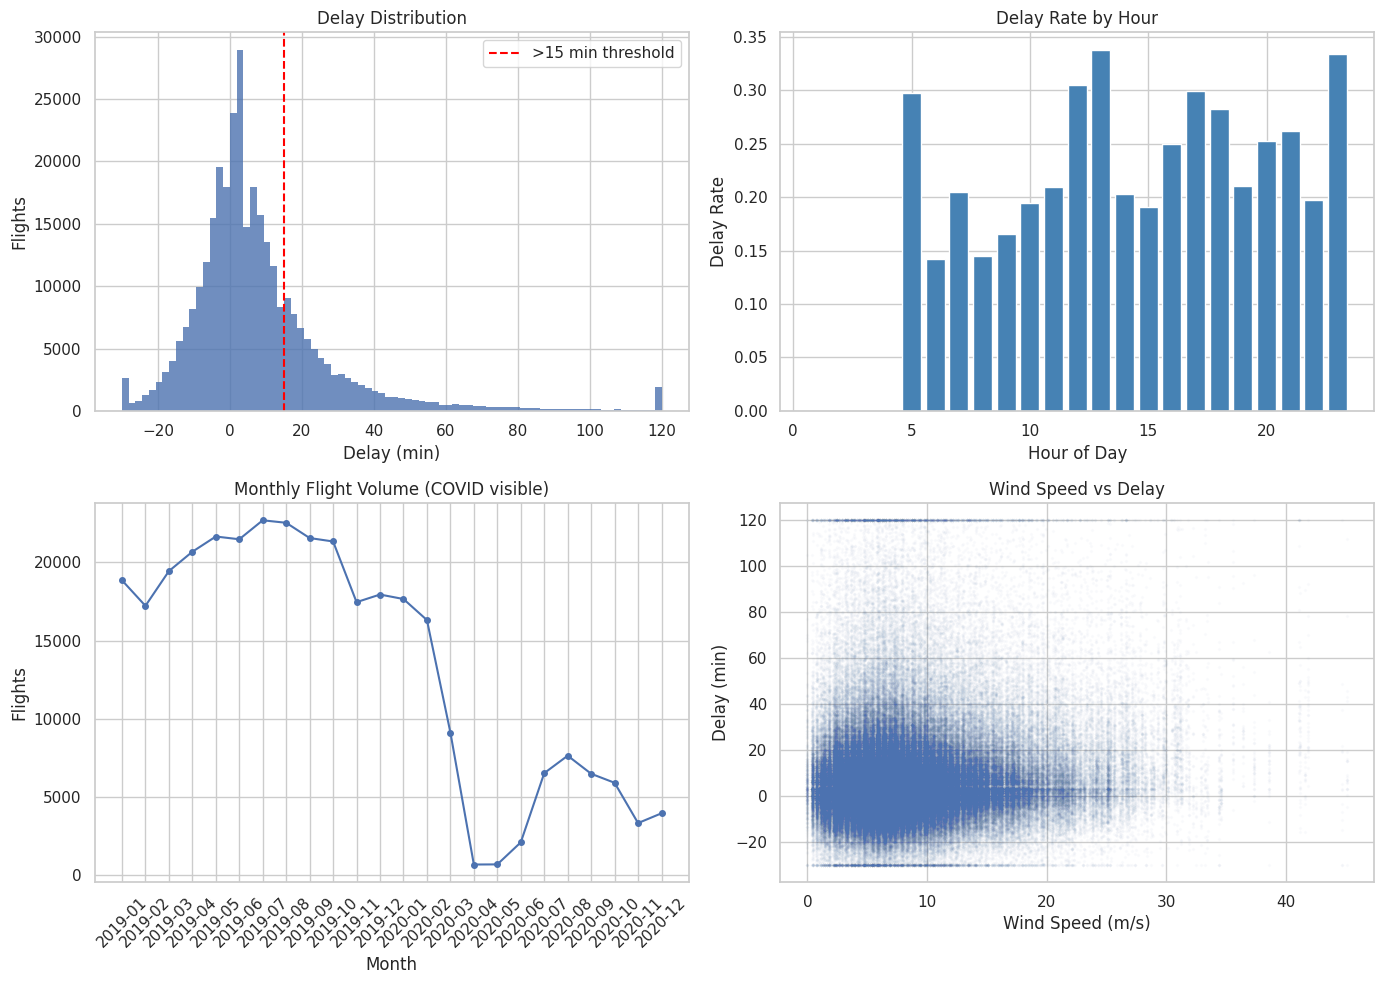

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Delay distribution (clipped for readability)
axes[0, 0].hist(
    df["delay_minutes"].clip(-30, 120), bins=80, edgecolor="none", alpha=0.8
)
axes[0, 0].axvline(15, color="red", ls="--", label=">15 min threshold")
axes[0, 0].set(
    xlabel="Delay (min)", ylabel="Flights", title="Delay Distribution"
)
axes[0, 0].legend()

# Delay rate by hour
hourly_rate = df.groupby("hour")["is_delayed"].mean()
axes[0, 1].bar(hourly_rate.index, hourly_rate.values, color="steelblue")
axes[0, 1].set(
    xlabel="Hour of Day", ylabel="Delay Rate", title="Delay Rate by Hour"
)

# Monthly flight volume (COVID impact)
monthly = df.groupby(df["date"].dt.to_period("M")).size()
axes[1, 0].plot(monthly.index.astype(str), monthly.values, marker="o", ms=4)
axes[1, 0].set(
    xlabel="Month",
    ylabel="Flights",
    title="Monthly Flight Volume (COVID visible)",
)
axes[1, 0].tick_params(axis="x", rotation=45)

# Weather vs delay
axes[1, 1].scatter(
    df["wind_speed_10m"], df["delay_minutes"].clip(-30, 120), alpha=0.02, s=2
)
axes[1, 1].set(
    xlabel="Wind Speed (m/s)",
    ylabel="Delay (min)",
    title="Wind Speed vs Delay",
)

plt.tight_layout()
plt.show()

## 7. Save Processed Data

Save the cleaned dataset so the Streamlit dashboard can load it directly.


In [48]:
save_cols = [
    "date",
    "scheduled_dt",
    "FLT",
    "carrier",
    "LSV",
    "Org/Des",
    "TAR",
    "gate_zone",
    "ACT",
    "RWY",
    "RWC",
    "hour",
    "minute",
    "day_of_week",
    "month",
    "is_weekend",
    "delay_minutes",
    "is_delayed",
    "has_delay_code",
    "temperature_2m",
    "wind_speed_10m",
    "wind_gusts_10m",
    "precipitation",
    "snowfall",
    "cloud_cover",
    "dest_lat",
    "dest_lon",
    "dest_country",
    "distance_km",
    "movements_per_hour",
]
df[save_cols].to_csv(PROCESSED_CSV, index=False)
print(f"Saved {len(df)} rows to {PROCESSED_CSV.name}")

Saved 323203 rows to flights_processed.csv


## 8. Prepare Features for ML

We use a mix of numeric and categorical features. Categorical features are label-encoded
so all models can consume them.


In [49]:
numeric_features = [
    "hour",
    "minute",
    "day_of_week",
    "month",
    "is_weekend",
    "temperature_2m",
    "wind_speed_10m",
    "wind_gusts_10m",
    "precipitation",
    "snowfall",
    "cloud_cover",
    "distance_km",
    "movements_per_hour",
]
categorical_features = ["carrier", "LSV", "ACT", "RWC", "gate_zone"]

label_encoders = {}
for col in categorical_features:
    le = LabelEncoder()
    df[col + "_enc"] = le.fit_transform(df[col].fillna("UNKNOWN").astype(str))
    label_encoders[col] = le

feature_cols = numeric_features + [c + "_enc" for c in categorical_features]

X = df[feature_cols].copy()
y = df["is_delayed"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(
    f"Train delay rate: {y_train.mean():.3f}, Test delay rate: {y_test.mean():.3f}"
)

Train: (258562, 18), Test: (64641, 18)
Train delay rate: 0.231, Test delay rate: 0.231


## 9. Train & Compare Models

We train four classifiers **with class-weight balancing** to handle the
imbalanced target, then **optimise the decision threshold** per model
(maximising F1 on the test set) before comparing.


In [ ]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_weight = neg / pos
print(
    f"Class ratio  neg:pos = {neg}:{pos}  ->  scale_pos_weight = {scale_weight:.2f}\n"
)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, random_state=42, class_weight="balanced"
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=12,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        eval_metric="logloss",
        scale_pos_weight=scale_weight,
    ),
}

results = {}
trained_models = {}
best_thresholds = {}

sample_weights = np.where(y_train == 1, scale_weight, 1.0)

for name, model in models.items():
    print(f"Training {name}...")
    pipe = Pipeline(
        [
            ("scaler", StandardScaler()),
            ("clf", model),
        ]
    )
    if name == "Gradient Boosting":
        pipe.fit(X_train, y_train, clf__sample_weight=sample_weights)
    else:
        pipe.fit(X_train, y_train)
    trained_models[name] = pipe

    y_proba = pipe.predict_proba(X_test)[:, 1]

    thresholds = np.arange(0.10, 0.91, 0.01)
    f1s = [
        f1_score(y_test, (y_proba >= t).astype(int), zero_division=0)
        for t in thresholds
    ]
    best_t = float(thresholds[np.argmax(f1s)])
    best_thresholds[name] = round(best_t, 2)

    y_pred = (y_proba >= best_t).astype(int)

    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "threshold": best_t,
    }
    print(
        f"  -> ROC-AUC: {results[name]['roc_auc']:.4f}  "
        f"F1: {results[name]['f1']:.4f}  (threshold={best_t:.2f})"
    )

print("\nDone.")

Class ratio  neg:pos = 198785:59777  ->  scale_pos_weight = 3.33

Training Logistic Regression...
  -> ROC-AUC: 0.6613  F1: 0.4309  (threshold=0.49)
Training Random Forest...
  -> ROC-AUC: 0.7518  F1: 0.5022  (threshold=0.49)
Training Gradient Boosting...
  -> ROC-AUC: 0.7624  F1: 0.5142  (threshold=0.53)
Training XGBoost...
  -> ROC-AUC: 0.7619  F1: 0.5123  (threshold=0.53)

Done.


## 10. Model Comparison Table


In [56]:
comparison_df = pd.DataFrame(results).T.sort_values("roc_auc", ascending=False)
comparison_df.style.format("{:.4f}").highlight_max(axis=0, color="lightgreen")

,accuracy,precision,recall,f1,roc_auc,threshold
Gradient Boosting,0.7242,0.4337,0.6312,0.5142,0.7624,0.5300
XGBoost,0.7236,0.4326,0.6281,0.5123,0.7619,0.5300
Random Forest,0.7041,0.4109,0.6457,0.5022,0.7518,0.4900
Logistic Regression,0.6099,0.3251,0.6389,0.4309,0.6613,0.4900


## 11. ROC Curves


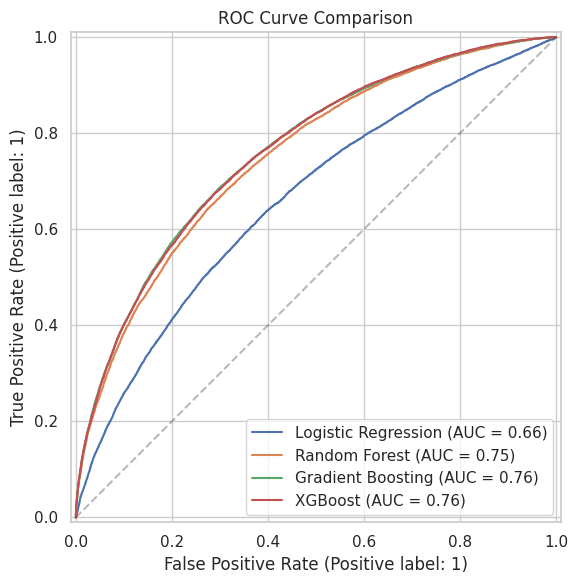

In [52]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, pipe in trained_models.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
ax.set_title("ROC Curve Comparison")
plt.tight_layout()
plt.show()

## 12. Confusion Matrices


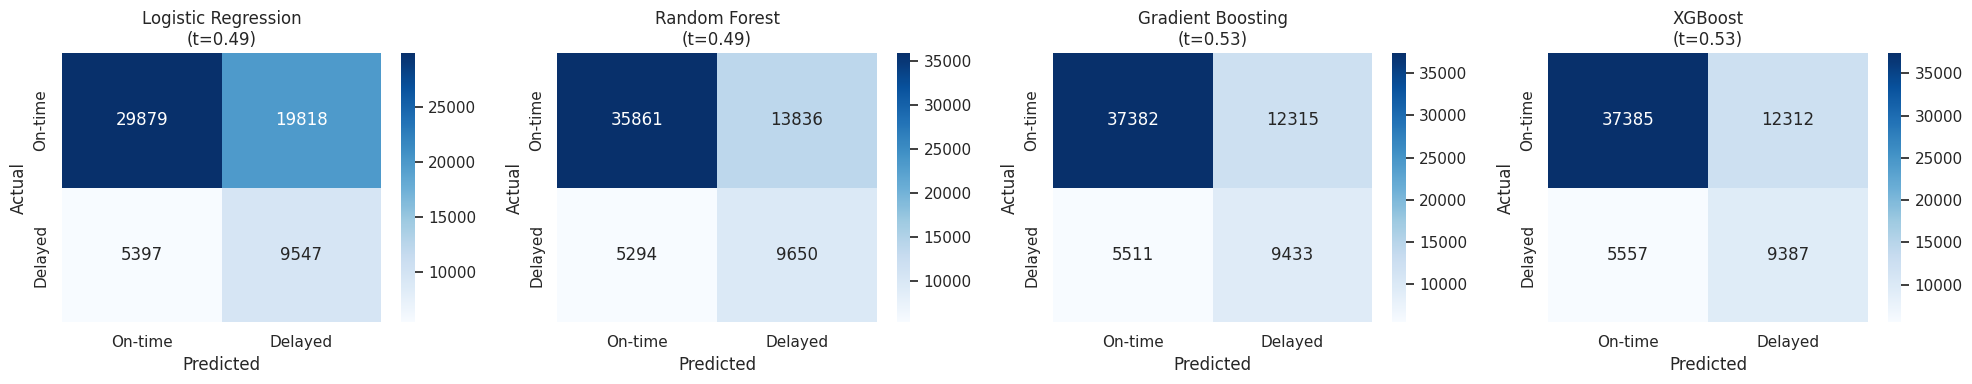

In [53]:
fig, axes = plt.subplots(
    1, len(trained_models), figsize=(5 * len(trained_models), 4)
)
for ax, (name, pipe) in zip(axes, trained_models.items()):
    y_proba = pipe.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= best_thresholds[name]).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        xticklabels=["On-time", "Delayed"],
        yticklabels=["On-time", "Delayed"],
    )
    ax.set_title(f"{name}\n(t={best_thresholds[name]:.2f})")
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")
plt.tight_layout()
plt.show()

## 13. Feature Importance (Best Model)


Best model: Gradient Boosting


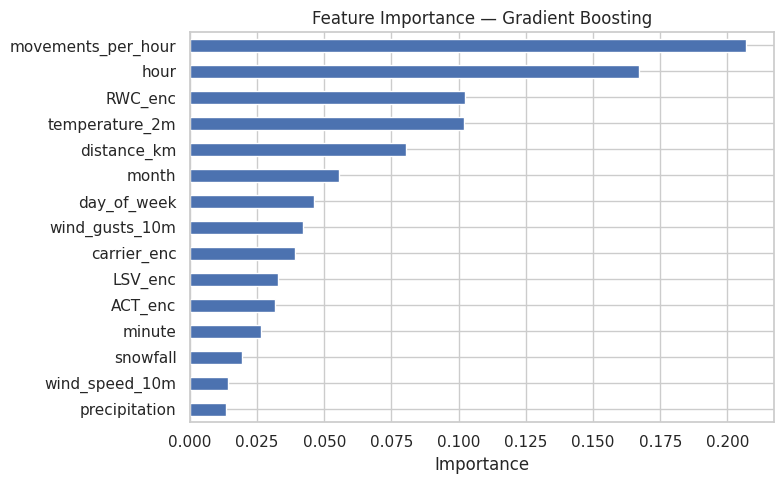

In [54]:
best_name = comparison_df.index[0]
best_pipe = trained_models[best_name]
print(f"Best model: {best_name}")

clf = best_pipe.named_steps["clf"]
if hasattr(clf, "feature_importances_"):
    importances = pd.Series(
        clf.feature_importances_, index=feature_cols
    ).sort_values()
    importances.tail(15).plot.barh(
        figsize=(8, 5), title=f"Feature Importance — {best_name}"
    )
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    print("(Logistic Regression selected — showing coefficient magnitudes)")
    coefs = pd.Series(np.abs(clf.coef_[0]), index=feature_cols).sort_values()
    coefs.tail(15).plot.barh(
        figsize=(8, 5), title=f"Coefficient Magnitude — {best_name}"
    )
    plt.xlabel("|Coefficient|")
    plt.tight_layout()
    plt.show()

## 14. Save Best Model & Metadata


In [55]:
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(best_pipe, BEST_MODEL_PATH)
print(f"Saved best model ({best_name}) -> {BEST_MODEL_PATH.name}")

comparison_out = {
    name: {k: round(v, 4) for k, v in metrics.items()}
    for name, metrics in results.items()
}
comparison_out["_best_model"] = best_name
comparison_out["_thresholds"] = best_thresholds

with open(MODEL_COMPARISON_PATH, "w") as f:
    json.dump(comparison_out, f, indent=2)
print(f"Saved model comparison -> {MODEL_COMPARISON_PATH.name}")

with open(FEATURE_COLUMNS_PATH, "w") as f:
    json.dump(
        {
            "feature_cols": feature_cols,
            "categorical_features": categorical_features,
            "label_encoders": {
                k: list(le.classes_) for k, le in label_encoders.items()
            },
        },
        f,
        indent=2,
    )
print(f"Saved feature metadata -> {FEATURE_COLUMNS_PATH.name}")

# Also save all trained models for the dashboard comparison page
for name, pipe in trained_models.items():
    safe_name = name.lower().replace(" ", "_")
    joblib.dump(pipe, ARTIFACTS_DIR / f"model_{safe_name}.joblib")
print(f"Saved all {len(trained_models)} models to artifacts/")

Saved best model (Gradient Boosting) -> best_model.joblib
Saved model comparison -> model_comparison.json
Saved feature metadata -> feature_columns.json
Saved all 4 models to artifacts/
